## 1. Image Enhancement in Spatial Domain


### 1.1 Gray Level Transformations


### 1.1.1 Image Negative


Image negative is a point processing transformation that reverses the intensity levels of an image meaning dark pixels become bright and bright pixels become dark, producing a reversed-tone version (like a photo film negative).

For an 8-bit grayscale image:

$$
s = (L-1)-r
$$

Where, <br>
$\qquad L =$ Number of gray levels (256 for 8-bit) <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>


**Program to implement image negative**


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread("images/img-1.png", 1)

if img is None:
    print("Image not found!")
    exit()

rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [3]:
negative = cv2.bitwise_not(rgb_img)

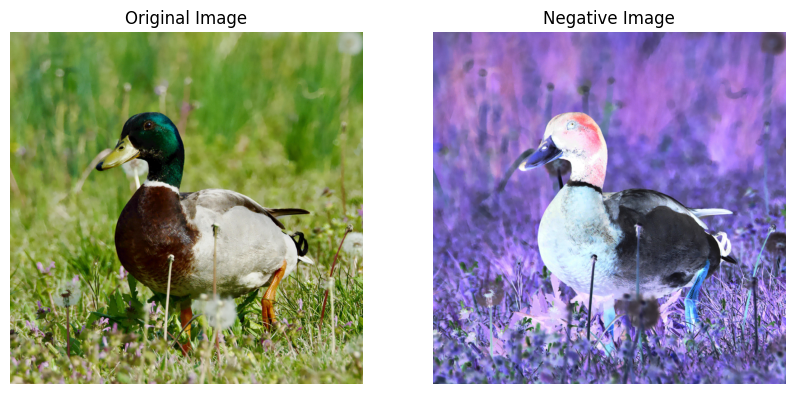

In [4]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(rgb_img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Negative Image")
plt.imshow(negative)
plt.axis("off")

plt.show()

### 1.1.2 Log Transformation


Log transformation is a gray-level transformation technique that maps a narrow range of low-intensity (dark) pixel values to a wider range of output values, thereby enhancing the details in darker regions of an image.

$$
s = c \cdot \text{log}(1+r)
$$

Where, <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>
$\qquad c =$ Scaling constant, defined as: <br>

$$
c = \frac{255}{\text{log}(1+r_{max})}
$$

$\qquad r_{max} =$ maximum pixel value in the input image (usually 255)


**Program to implement log transformation**


In [5]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [6]:
img_float = np.float32(gray_img)

log_transformed = np.log1p(img_float)
log_transformed = cv2.normalize(log_transformed, None, 0, 255, cv2.NORM_MINMAX)
log_transformed = np.uint8(log_transformed)

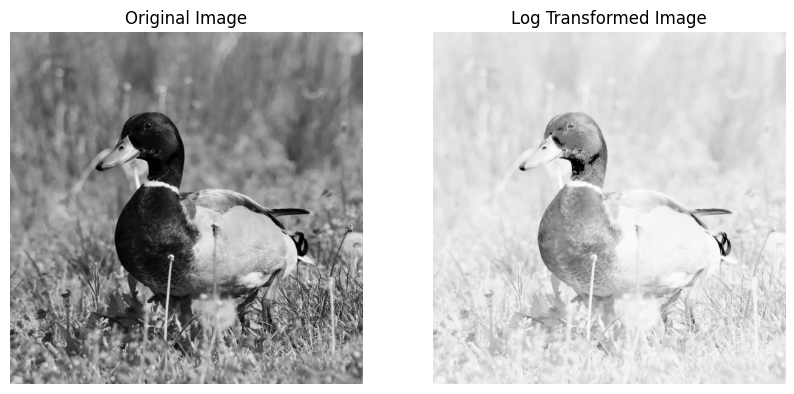

In [7]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(gray_img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Log Transformed Image")
plt.imshow(log_transformed, cmap="gray")
plt.axis("off")

plt.show()

### 1.1.3 Power-Law (Gamma) Transformation


Power-law transformation, also called Gamma Transformation, is used in image processing to enhance an image by modifying its brightness levels using a power function. It is useful for brightness correction, gamma correction and enhancing dark or bright regions.

$$
s = c \cdot r^{\gamma}
$$

Where, <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>
$\qquad c =$ Constant (usually 1) <br>
$\qquad \gamma =$ Gamma value <br>

Effect of Gamma Value <br>
$\qquad$ When $\gamma < 1$ then image becomes brighter <br>
$\qquad$ When $\gamma > 1$ then image becomes darker <br>
$\qquad$ When $\gamma = 1$ then no change <br>



In [11]:
img_float = gray_img / 255.0

gamma = 0.5

gamma_corrected = np.power(img_float, gamma)
gamma_corrected = np.uint8(gamma_corrected * 255)

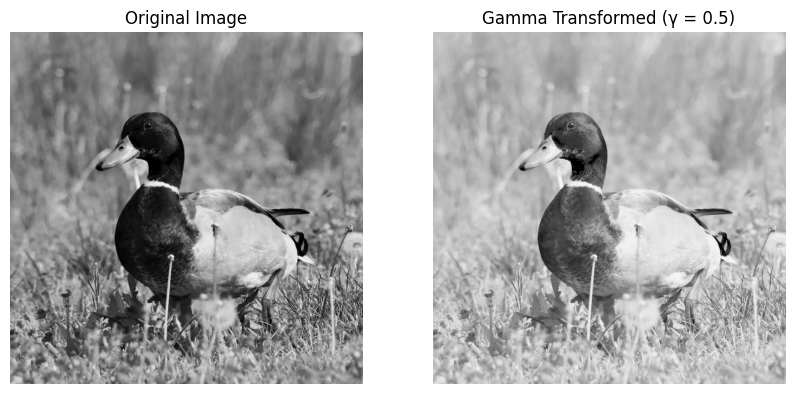

In [12]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(gray_img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"Gamma Transformed (γ = {gamma})")
plt.imshow(gamma_corrected, cmap="gray")
plt.axis("off")

plt.show()

# **Thresholding**

Thresholding is a simple yet powerful segmentation technique that converts a grayscale image into a binary image (black and white) by comparing each pixel's intensity to a fixed value called the threshold value ($T$). Mathematically, it is defined as,

$$
s = \begin{cases} 255 & \text{if } r \geq T \\ 0 & \text{if } r < T \end{cases}
$$

Where, <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>
$\qquad T =$ Threshold value <br>


In [8]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 60, 255, cv2.THRESH_BINARY)

cv2.imshow("Threshold", thresh)

cv2.waitKey(0)
cv2.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/pranish/Coding/ImageProcessing/venv/lib/python3.14/site-packages/cv2/qt/plugins"
QFontDatabase: Cannot find font directory /home/pranish/Coding/ImageProcessing/venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/pranish/Coding/ImageProcessing/venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/pranish/Coding/ImageProcessing/venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/pranish/Coding/ImageProcessing/venv/lib/pytho

In [9]:
ret, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

cv2.imshow("Automatic", otsu)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [10]:
adaptive = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

cv2.imshow("Adaptive", adaptive)

cv2.waitKey(0)
cv2.destroyAllWindows()